# Homework 4

## FINM 35700 - Spring 2026

Garrett White

In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

extract_path = "/content/unzipped_files"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"\nExtracted to: {extract_path}\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Saving UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_4.zip to UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_4.zip

Extracted to: /content/unzipped_files

unzipped_files/
  UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_4/
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Advanced.ipynb
    credit_market_tools.py
    FINM_35700_CreditMarkets_Spring2026_Homework_4.ipynb
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Basics.ipynb
    data/
      hyg_basket_composition.xlsx
      govt_on_the_run.xlsx
      cds_market_data_eod.xlsx
      bond_market_prices_eod.xlsx
      sofr_swaps_market_data_eod.xlsx
      hyg_corp_symbology.xlsx
      bond_symbology.xlsx
      sofr_swaps_symbology.xlsx
      call_schedules.xlsx
      ~$call_schedules.xlsx


This homework relies on:

Interest Rate & Credit Default Swaps
- the SOFR OIS symbology file `sofr_swap_symbology`,
- the SOFR swaps market data file `sofr_swaps_market_data_eod`,
- the CDS spreads market data file `cds_market_data_eod`.

HYG ETF corporate bonds:
- the HYG bond symbology file `hyg_bond_symbology` and
- the HYG basket composition file (containing bond weights and yields) `hyg_basket_composition`.

In [7]:
import sys

base_path = "/content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_4"

sys.path.append(base_path)

from credit_market_tools import *

print("credit_market_tools imported successfully")

credit_market_tools imported successfully


In [4]:
!pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 59.7 MB/s eta 0:00:00


In [10]:
import QuantLib as ql
import pandas as pd
from credit_market_tools import *

calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

as_of_date = pd.to_datetime('2026-03-23')

-----------------------------------------------------------
# Problem 1: Fixed rate bond prices and sensitivities (bond yield model)

## When computing sensitivities, assume "everything else being equal" (ceteris paribus).

For a better understanding of dependencies, you can use the simple fixed rate bond valuation formula in the flat yield model (formula [6] in Lecture 1).

\begin{align}
PV_{Bond}\left(c,T,y_{sa} \right)=1+\frac{c-y_{sa}}{y_{sa}}\cdot\left[1-\left(1+\frac{y_{sa}}{2}\right)^{-2T}\right]
\end{align}


## a. True or False (fixed rate bond prices)

1. Fixed rate bond price is increasing in yield.
2. Fixed rate bond price is increasing in coupon
3. Fixed rate bond price is increasing in bond maturity
4. Fixed rate callable bond prices are higher or equal to their "bullet" (non-callable) version.


# Part a):

1. False
   Bond price is decreasing in yield (discount rate increases → PV falls).

2. True  
   Higher coupon → higher cash flows → higher bond price.

3. False
   Bond price is not monotonically increasing in maturity.  
   Effect depends on whether coupon is above or below yield.

4. False
   A callable bond is always less than or equal to a bullet bond  
   (issuer call option is a disadvantage to investor).

## b. True or False (fixed rate bond yields)

1. Fixed rate bond yield is increasing in interest rate (assuming credit spread unchanged)    
2. Fixed rate bond yield is increasing in credit spread (assuming interest rate unchanged)    
3. Fixed rate bond yield is increasing in coupon
4. Fixed rate bond yield is increasing in bond maturity (assume term structure of yield curve is known)


## Part b)

1. True  
   Bond yield reflects the risk-free rate component, so higher interest rates increase yield (holding spread fixed).

2. True  
   Higher credit spread increases required return, so bond yield increases.

3. False  
   Yield is not increasing in coupon; higher coupons generally lead to lower yield for a given price.

4. False  
   Yield is not mechanically increasing in maturity if the yield curve is known; it depends on the term structure shape.

## c. True or False (fixed rate bond durations)

1. Fixed rate bond duration is increasing with yield
2. Fixed rate bond duration is increasing in coupon
3. Fixed rate bond duration is increasing with bond maturity
4. Fixed rate callable bond durations are higher or equal to their "bullet" (non-callable) version.


## Part c)

1. False  
   Duration decreases as yield increases (higher discounting reduces sensitivity).

2. False  
   Higher coupon → more early cash flow → lower duration.

3. True  
   Longer maturity generally increases duration (more weighted cash flows further out).

4. False  
   Callable bond duration is lower or equal to bullet bond duration  
   (call option reduces interest rate sensitivity).

## d. True or False (fixed rate bond convexities)

1. Fixed rate bond convexity is increasing with yield
2. Fixed rate bond convexity is increasing in coupon
3. Fixed rate bond convexity is increasing with bond maturity
4. Fixed rate callable bond convexities are higher or equal to their "bullet" (non-callable) version.


## Part d)

1. False  
   Convexity generally decreases as yield increases (higher discounting reduces curvature).

2. False  
   Higher coupon reduces convexity (more early cash flows reduce curvature).

3. True  
   Longer maturity increases convexity (cash flows are further in the future).

4. False  
   Callable bond convexity is lower or equal to bullet bond convexity  
   (call option reduces positive curvature / introduces negative convexity).

-----------------------------------------------------------
# Problem 2: US SOFR swap curve calibration as of 2026-03-23
### Follow Section "1. SOFR OIS swap rates and SOFR discount curve calibration + validation" in the QuantLib Advanced notebook !

## a. Load and explore US SOFR swaps symbology and market data

Load the `sofr_swap_symbology` Excel file into a dataframe. Print all swap tenors available.

Load the `sofr_swaps_market_data_eod` Excel file into a dataframe. Print all dates available.

Plot the historial time series of SOFR rates for the available [1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y] tenors.

Available tenors (symbology):
[np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(10), np.int64(20), np.int64(30)]

Available dates (market data):
556 unique dates
min date: 2024-01-02 00:00:00
max date: 2026-03-23 00:00:00
1Y points: 556
2Y points: 554
3Y points: 554
5Y points: 554
7Y points: 554
10Y points: 554
20Y points: 554
30Y points: 554


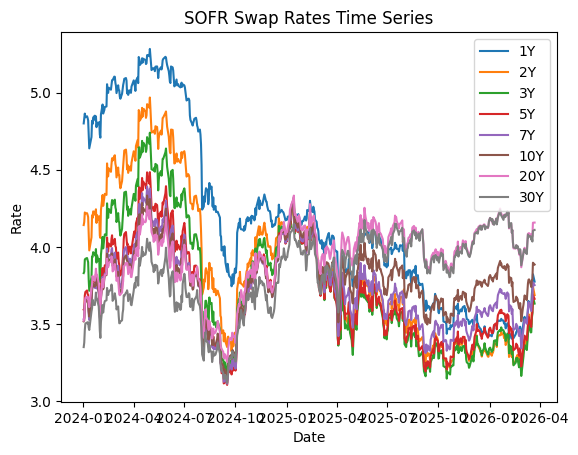

In [16]:
import matplotlib.pyplot as plt

data_path = f"{base_path}/data"

# load files
symbology = pd.read_excel(f"{data_path}/sofr_swaps_symbology.xlsx")
market = pd.read_excel(f"{data_path}/sofr_swaps_market_data_eod.xlsx")

# print required info
print("Available tenors (symbology):")
print(sorted(symbology["tenor"].unique()))

print("\nAvailable dates (market data):")
print(market["date"].nunique(), "unique dates")
print("min date:", market["date"].min())
print("max date:", market["date"].max())

# ensure datetime
market["date"] = pd.to_datetime(market["date"])

# merge
df = market.merge(symbology[["figi", "tenor"]], on="figi", how="left")

# plot
rate_col = "midRate"
target_tenors = [1, 2, 3, 5, 7, 10, 20, 30]

plt.figure()

for t in target_tenors:
    sub = df[df["tenor"] == t].sort_values("date")
    print(f"{t}Y points:", len(sub))
    if len(sub) > 0:
        plt.plot(sub["date"], sub[rate_col], label=f"{t}Y")

plt.title("SOFR Swap Rates Time Series")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.show()

## b. Calibrate the US SOFR yield curve (via bootstrapping)
The function below shows how to calibrate a smooth yield/discount factor curve from SOFR swaps.

Prepare a joint symbology & market dataframe quotes as of 2026-03-23.

Calibrate the SOFR discount factor curve as of 2026-03-23.

Follow section 1b in the QuantLib Advanced notebook.

In [18]:
def calibrate_sofr_curve_from_frame(
        calc_date: ql.Date,
        sofr_details: pd.DataFrame,
        rate_quote_column: str):
    '''Create a calibrated yield curve from a SOFR details dataframe which includes rate quotes.
    '''
    ql.Settings.instance().evaluationDate = calc_date

    # Sort dataframe by maturity
    sorted_details_frame = sofr_details.sort_values(by='tenor')

    # settle_days
    settle_days = 1

    # For US SOFR OIS Swaps
    day_count = ql.Actual360()

    # For US SOFR Swaps
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

    sofr_helpers = []

    for index, row in sorted_details_frame.iterrows():
        sofr_quote = row[rate_quote_column]
        tenor_in_years = row['tenor']
        sofr_tenor = ql.Period(tenor_in_years, ql.Years)

        # create sofr_rate_helper
        sofr_helper = ql.OISRateHelper(settle_days, sofr_tenor, ql.QuoteHandle(ql.SimpleQuote(sofr_quote/100)), ql.Sofr())

        sofr_helpers.append(sofr_helper)

    sofr_yield_curve = ql.PiecewiseLinearZero(settle_days, calendar, sofr_helpers, day_count)
    sofr_yield_curve.enableExtrapolation()

    return sofr_yield_curve

In [24]:
# evaluation date
calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

# filter to as-of date
as_of_date = pd.to_datetime("2026-03-23")
df_asof = df[df["date"] == as_of_date].copy()

# clean + sort
df_asof = df_asof[["tenor", "midRate"]].dropna()
df_asof["tenor"] = df_asof["tenor"].astype(int)
df_asof = df_asof.sort_values("tenor")

# build helpers EXACTLY like advanced notebook
sofr_helpers = []

for _, row in df_asof.iterrows():
    tenor = int(row["tenor"])
    rate = float(row["midRate"])

    helper = ql.OISRateHelper(
        1,
        ql.Period(tenor, ql.Years),
        ql.QuoteHandle(ql.SimpleQuote(rate / 100)),
        ql.Sofr()
    )

    sofr_helpers.append(helper)

# bootstrap curve (same as notebook)
sofr_curve = ql.PiecewiseLinearZero(
    1,
    ql.UnitedStates(ql.UnitedStates.GovernmentBond),
    sofr_helpers,
    ql.Actual360()
)

sofr_curve.enableExtrapolation()

print("Curve reference date:", sofr_curve.referenceDate())

Curve reference date: March 24th, 2026


## c. Display the calibrated SOFR discount curve dataframe

Follow section 1d (in the QuantLib Advanced notebook) to display the calibration details dataframe.

In [26]:
sofr_yield_curve_handle = ql.YieldTermStructureHandle(sofr_curve)

In [27]:
sofr_yield_curve_details_df = get_yield_curve_details_df(sofr_curve)
sofr_yield_curve_details_df

,Date,YearFrac,DiscountFactor,ZeroRate
0,2026-03-24,0.000,1.000,3.773
1,2027-03-24,1.014,0.963,3.773
2,2028-03-24,2.031,0.929,3.684
3,2029-03-26,3.050,0.897,3.627
4,2031-03-24,5.072,0.833,3.662
5,2033-03-24,7.103,0.769,3.760
6,2036-03-24,10.147,0.678,3.911
7,2046-03-26,20.297,0.429,4.254
8,2056-03-24,30.439,0.291,4.141


## d. Plot the calibrated US SOFR Zero Interest Rates and Discount Factor curves

Plot the SOFR zero rates and discount factor curves by maturity. Follow section 1c in the QuantLib Advanced notebook.

Tenor 1.0 PV: -0.00023879251583114325
Tenor 2.0 PV: -0.000768988106988111
Tenor 3.0 PV: -0.0005224817714903907
Tenor 5.0 PV: 0.00028333236317479304
Tenor 7.0 PV: 0.0007315959286344764
Tenor 10.0 PV: 0.0010138472059537662
Tenor 20.0 PV: 0.0009506105779166774
Tenor 30.0 PV: 0.00031578107592622473


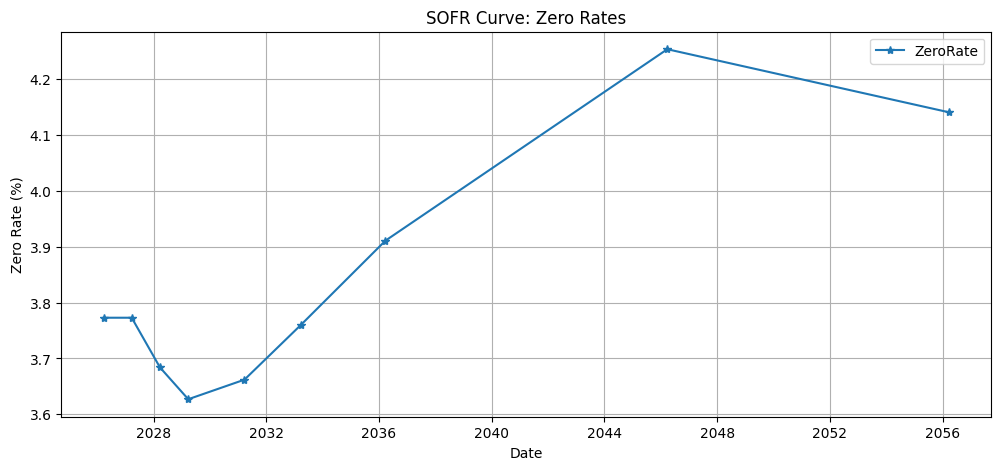

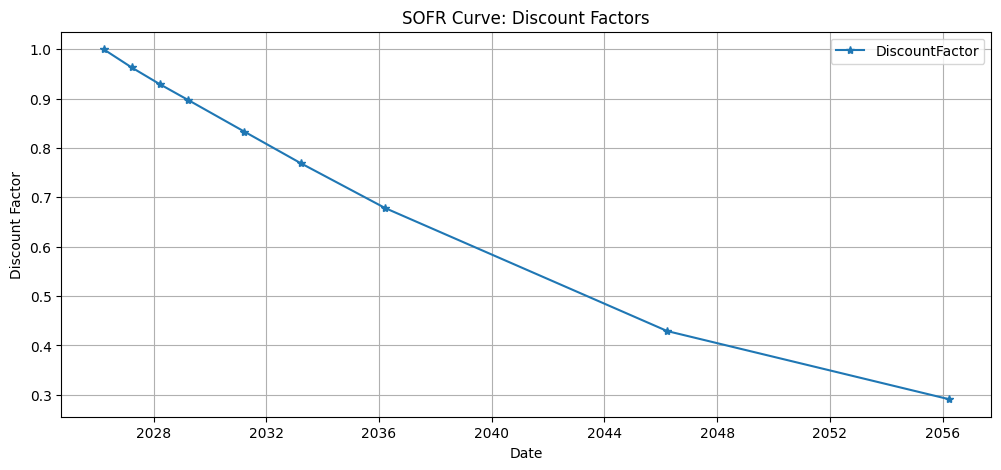

In [32]:
# ensure handle exists
sofr_yield_curve_handle = ql.YieldTermStructureHandle(sofr_curve)

# build calibration dataframe (from curve)
sofr_yield_curve_details_df = get_yield_curve_details_df(sofr_curve)

ax = sofr_yield_curve_details_df.plot(
    x="Date",
    y="ZeroRate",
    grid=True,
    style="*-",
    title="SOFR Curve: Zero Rates",
    figsize=(12, 5)
)
ax.set_ylabel("Zero Rate (%)")
ax.set_xlabel("Date")

ax = sofr_yield_curve_details_df.plot(
    x="Date",
    y="DiscountFactor",
    grid=True,
    style="*-",
    title="SOFR Curve: Discount Factors",
    figsize=(12, 5)
)
ax.set_ylabel("Discount Factor")
ax.set_xlabel("Date")


for _, row in df_asof.iterrows():
    tenor = ql.Period(int(row["tenor"]), ql.Years)
    rate = float(row["midRate"])

    oisSwap = ql.MakeOIS(
        tenor,
        ql.Sofr(sofr_yield_curve_handle),
        rate / 100,
        nominal=100
    )

    oisSwap.setPricingEngine(
        ql.DiscountingSwapEngine(sofr_yield_curve_handle)
    )

    print("Tenor", row["tenor"], "PV:", oisSwap.NPV())

-----------------------------------------------------------
# Problem 3: CDS Hazard Rate calibration and valuation
## Follow Section "2. CDS Hazard Rate calibration + Pricing" in the QuantLib Advanced notebook !!!

## a. Load and explore the CDS market data (IBM credit issuer)

Load the `cds_market_data_eod` Excel file into a dataframe. It contains CDS Par Spreads (in bps) for IBM credit issuer, from January 2024 until March 2026.

Plot the historical time series of CDS Par Spreads for the available tenors.


        date ticker                short_name    tier currency doc_clause  \
0 2024-01-02    IBM  Intl Business Machs Corp  SNRFOR      USD       XR14   
1 2024-01-03    IBM  Intl Business Machs Corp  SNRFOR      USD       XR14   
2 2024-01-04    IBM  Intl Business Machs Corp  SNRFOR      USD       XR14   
3 2024-01-05    IBM  Intl Business Machs Corp  SNRFOR      USD       XR14   
4 2024-01-08    IBM  Intl Business Machs Corp  SNRFOR      USD       XR14   

   running_coupon  cds_assumed_recovery  par_spread_1y  par_spread_2y  \
0             100                   0.4        13.6831        18.8194   
1             100                   0.4        14.2256        19.6610   
2             100                   0.4        13.8318        19.1828   
3             100                   0.4        13.6181        18.7703   
4             100                   0.4        13.4433        18.3692   

   par_spread_3y  par_spread_5y  par_spread_7y  par_spread_10y  
0        28.3917        44.7053  

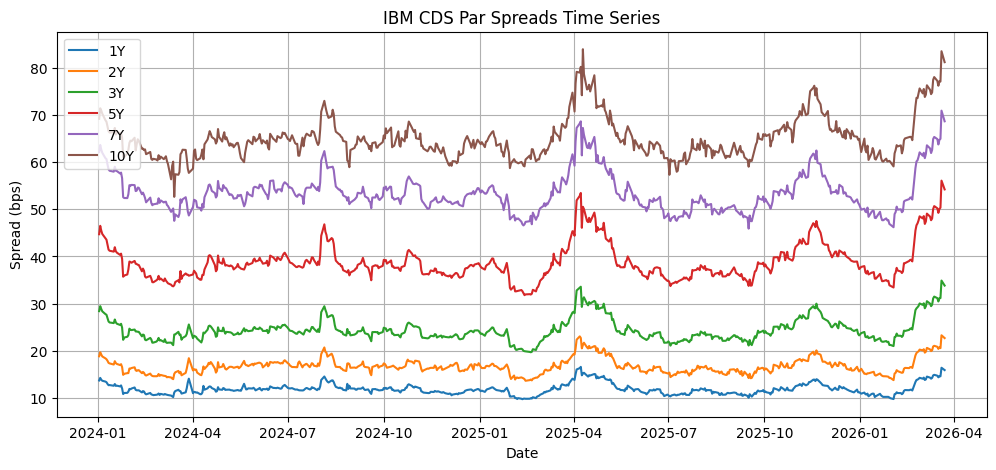

In [34]:
data_path = f"{base_path}/data"

cds = pd.read_excel(f"{data_path}/cds_market_data_eod.xlsx")

cds["date"] = pd.to_datetime(cds["date"])

print(cds.head())

tenors = [1, 2, 3, 5, 7, 10]

plt.figure(figsize=(12,5))

for t in tenors:
    col = f"par_spread_{t}y"
    if col in cds.columns:
        plt.plot(cds["date"], cds[col], label=f"{t}Y")

plt.title("IBM CDS Par Spreads Time Series")
plt.xlabel("Date")
plt.ylabel("Spread (bps)")
plt.legend()
plt.grid(True)
plt.show()

## b. Calibrate the IBM hazard rate curve as of 2026-03-23

Follow section 2a in the QuantLib Advanced notebook. Use the calibrated SOFR discount curve from Problem 2b.

In [36]:
# evaluation date (must match SOFR curve)
calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

# constants (from advanced notebook)
CDS_recovery_rate = 0.4
CDS_day_count = ql.Actual360()

settle_days = 1
calendar = ql.TARGET()

# CDS tenors
CDS_tenors = [ql.Period(y, ql.Years) for y in [1, 2, 3, 5, 7, 10]]

# filter CDS data to valuation date
cds_asof = cds[cds["date"] == pd.to_datetime("2026-03-23")].copy()

# map tenor -> spread (bps)
spread_map = {
    1: cds_asof["par_spread_1y"].values[0],
    2: cds_asof["par_spread_2y"].values[0],
    3: cds_asof["par_spread_3y"].values[0],
    5: cds_asof["par_spread_5y"].values[0],
    7: cds_asof["par_spread_7y"].values[0],
    10: cds_asof["par_spread_10y"].values[0],
}

# build CDS helpers (IMPORTANT: uses SOFR curve)
CDS_helpers = []

for tenor in CDS_tenors:
    y = tenor.length()

    spread = spread_map[y]

    helper = ql.SpreadCdsHelper(
        spread / 10000.0,
        tenor,
        settle_days,
        calendar,
        ql.Quarterly,
        ql.Following,
        ql.DateGeneration.TwentiethIMM,
        CDS_day_count,
        CDS_recovery_rate,
        ql.YieldTermStructureHandle(sofr_curve)
    )

    CDS_helpers.append(helper)

# bootstrap hazard curve
hazard_rate_curve = ql.PiecewiseFlatHazardRate(
    calc_date,
    CDS_helpers,
    CDS_day_count
)

hazard_rate_curve.enableExtrapolation()

# wrap in handle
hazard_rate_curve_handle = ql.DefaultProbabilityTermStructureHandle(hazard_rate_curve)

print("Hazard curve calibrated at:", hazard_rate_curve.referenceDate())

hazard_list = [
    (
        hr[0].to_date(),
        CDS_day_count.yearFraction(calc_date, hr[0]),
        hr[1] * 100,
        hazard_rate_curve.survivalProbability(hr[0])
    )
    for hr in hazard_rate_curve.nodes()
]

grid_dates, year_frac, hazard_rates, surv_probs = zip(*hazard_list)

hazard_rates_df = pd.DataFrame({
    "Date": grid_dates,
    "YearFrac": year_frac,
    "HazardRate": hazard_rates,
    "SurvivalProb": surv_probs
})

hazard_rates_df

Hazard curve calibrated at: March 23rd, 2026


,Date,YearFrac,HazardRate,SurvivalProb
0,2026-03-23,0.000000,0.263483,1.000000
1,2027-06-21,1.263889,0.263483,0.996675
2,2028-06-20,2.277778,0.522819,0.991406
3,2029-06-20,3.291667,1.005213,0.981353
4,2031-06-20,5.319444,1.520002,0.951567
5,2033-06-20,7.350000,1.897243,0.915606
6,2036-06-20,10.394444,2.019632,0.861004


## c. Plot the calibrated Hazard Rates and Survival Probability curves
Follow section 2b in the QuantLib Advanced notebook. Use the calibrated SOFR discount curve from Problem 2b.

Text(0.5, 0, 'Date')

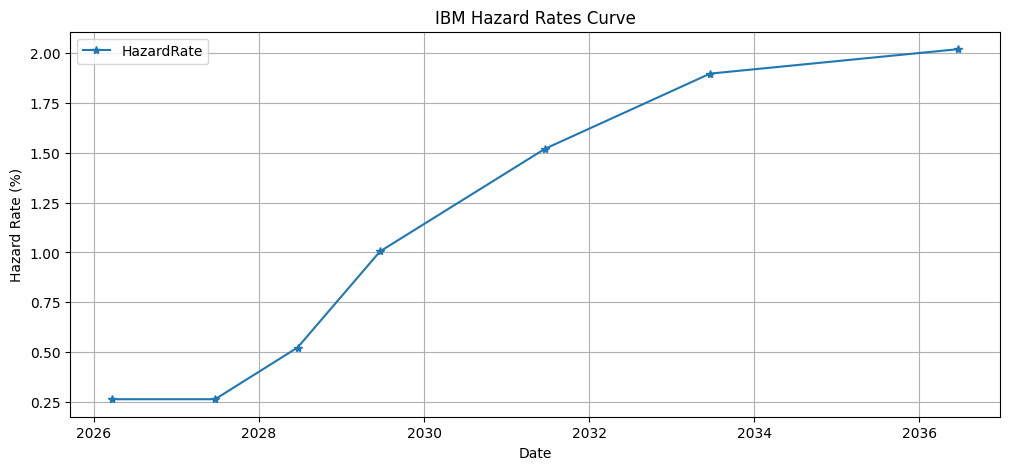

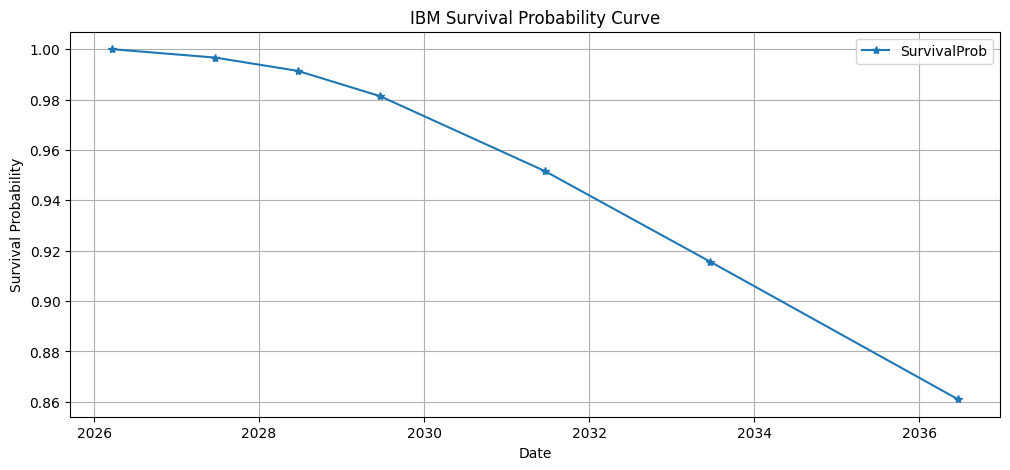

In [37]:
ax = hazard_rates_df.plot(
    x="Date",
    y="HazardRate",
    grid=True,
    style="*-",
    title="IBM Hazard Rates Curve",
    figsize=(12, 5)
)
ax.set_ylabel("Hazard Rate (%)")
ax.set_xlabel("Date")

# Survival probabilities
ax = hazard_rates_df.plot(
    x="Date",
    y="SurvivalProb",
    grid=True,
    style="*-",
    title="IBM Survival Probability Curve",
    figsize=(12, 5)
)
ax.set_ylabel("Survival Probability")
ax.set_xlabel("Date")

## d. Compute the fair/par spread and PV of a 5 year CDS contract

Follow section 2c in the QuantLib Advanced notebook. Construct a CDS object with 100 bps coupon and 2031-06-20 maturity.

Compute the following CDS metrics:
- fair/par spread,
- PV,
- Premium Leg PV,
- Default Leg PV,
- Issuer survival probability to maturity.


In [39]:
side = ql.Protection.Seller
face_notional = 100
contractual_spread = 100 / 10000

cds_start_date = ql.Date(23, 3, 2026)
cds_maturity_date = ql.Date(20, 6, 2031)

# CDS schedule (as in advanced notebook)
cds_schedule = ql.MakeSchedule(
    cds_start_date,
    cds_maturity_date,
    ql.Period("3M"),
    ql.Quarterly,
    ql.TARGET(),
    ql.Following,
    ql.Unadjusted,
    ql.DateGeneration.TwentiethIMM
)

# CDS object
cds_obj = ql.CreditDefaultSwap(
    side,
    face_notional,
    contractual_spread,
    cds_schedule,
    ql.Following,
    ql.Actual360()
)

# pricing engine (uses SOFR + hazard curve)
cds_engine = ql.MidPointCdsEngine(
    hazard_rate_curve_handle,
    CDS_recovery_rate,
    sofr_yield_curve_handle
)

cds_obj.setPricingEngine(cds_engine)

print("CDS protection start date:", cds_obj.protectionStartDate())
print("CDS fair/par spread:", round(cds_obj.fairSpread() * 10000, 3))
print("CDS PV:", round(cds_obj.NPV(), 4))
print("CDS Premium Leg PV:", round(cds_obj.couponLegNPV(), 4))
print("CDS Default Leg PV:", round(cds_obj.defaultLegNPV(), 4))
print(
    "Survival Prob. to Maturity:",
    round(hazard_rate_curve.survivalProbability(cds_maturity_date), 4)
)

CDS protection start date: March 23rd, 2026
CDS fair/par spread: 54.194
CDS PV: 2.1721
CDS Premium Leg PV: 4.7419
CDS Default Leg PV: -2.5698
Survival Prob. to Maturity: 0.9516


-----------------------------------------------------------
# Problem 4: Credit ETF analysis on HYG (iShares High Yield Corporate Bond ETF)

## a. Load and explore the HYG basket composition and market data

Load the `hyg_basket_composition` Excel file into a dataframe. It contains the HYG basket constituent face notionals, weights and yields-to-maturities as of 2026-03-23.

Load the `hyg_corp_symbology` Excel file into a dataframe. It contains the corporate bond details for HYG constituents.

How many corporate bonds are in the HYG basket?  What are the average and median face notionals for a bond?

How many unique tickers are in the HYG basket? What are the average and median face notionals for a ticker?

Compute mean, median and standard deviation of yields-to-maturity of bonds in the basket.

In [41]:
data_path = f"{base_path}/data"

hyg_basket = pd.read_excel(f"{data_path}/hyg_basket_composition.xlsx")
hyg_symbology = pd.read_excel(f"{data_path}/hyg_corp_symbology.xlsx")

# inspect
print(hyg_basket.head())

print("\nNumber of bonds in HYG basket:", len(hyg_basket))

print("\nBond-level face notional stats:")
print("Mean:", hyg_basket["face_notional"].mean())
print("Median:", hyg_basket["face_notional"].median())

n_tickers = hyg_basket["etf_ticker"].nunique()
print("\nNumber of unique tickers:", n_tickers)

ticker_group = hyg_basket.groupby("etf_ticker")["face_notional"].sum()

print("\nTicker-level face notional stats:")
print("Mean:", ticker_group.mean())
print("Median:", ticker_group.median())

print("\nYield to Maturity stats:")
print("Mean:", hyg_basket["midYield"].mean())
print("Median:", hyg_basket["midYield"].median())
print("Std Dev:", hyg_basket["midYield"].std())

        date etf_ticker          figi          isin            security  \
0 2024-12-13        HYG  BBG00ZKWG886  US013822AG68   AA 4 1/8 03/31/29   
1 2024-12-13        HYG  BBG00VYJS3B3  US013822AE11   AA 5 1/2 12/15/27   
2 2024-12-13        HYG  BBG00KXCGK19  US013822AC54   AA 6 1/8 05/15/28   
3 2024-12-13        HYG  BBG01LW38YD3  US013822AH42   AA 7 1/8 03/15/31   
4 2024-12-13        HYG  BBG01F5TZPJ2  US023771T329  AAL 7 1/4 02/15/28   

                                         description  coupon   maturity  \
0  ALCOA NEDERLAND HOLDING BV 4.125 03/31/2029 14...   4.125 2029-03-31   
1  ALCOA NEDERLAND HOLDING BV 5.5 12/15/2027 144a...   5.500 2027-12-15   
2  ALCOA NEDERLAND HOLDING BV 6.125 05/15/2028 14...   6.125 2028-05-15   
3  ALCOA NEDERLAND HOLDING BV 7.125 03/15/2031 14...   7.125 2031-03-15   
4  AMERICAN AIRLINES INC 7.25 02/15/2028 144a (SE...   7.250 2028-02-15   

  cpn_type class currency  bidYield  askYield  midYield  face_notional  \
0    FIXED  Corp      US

## b. Compute the NAV of the HYG basket and the intrinsic price of one ETF share.

Create the bond objects for all constituents of HYG. For each bond, compute the clean price, accrued and dirty price (convert from yield-to-maturity). Remember that dirty price = clean price + accrued.

Aggregate the ETF NAV value (intrisic value of bond basket) as the weighted sum of dirty prices times basket weights. Keep in mind that the resulting ETF NAV will be on a face of $100, since the basket face notional weights add up to 100 percent.

Compute the intrinisc market capitalization of the HYG ETF by scaling the ETF NAV price to the ETF total face notional.

Divide by 202,500,000 (the number of ETF shared outstanding as of 2026-03-23) to obtain the intrinsic USD price of one HYG ETF share.

As a reference, the market/close price of each HYG share on 2026-03-23 was $79.44, and the NAV was $79.34.

In [54]:
as_of = pd.to_datetime("2026-03-23")

def flat_price(face, c, y, T):
    """
    Flat credit yield pricing (per bond, consistent units)
    """
    y = y / 100
    c = c / 100

    return face * (
        1 + (c - y) / y * (1 - (1 + y/2) ** (-2*T))
    )

etf_value = 0.0

for _, row in hyg.iterrows():

    face = row["face_notional"]
    c = row["coupon"]
    y = row["midYield"]

    T = (pd.to_datetime(row["maturity"]) - as_of).days / 365

    bond_value = flat_price(face, c, y, T)

    etf_value += bond_value

shares_outstanding = 202_500_000

etf_price = etf_value / shares_outstanding

print("ETF total value ($):", etf_value)
print("ETF intrinsic price ($):", etf_price)

ETF total value ($): 16368388274.563164
ETF intrinsic price ($): 80.83154703487982


## c. Compute the ETF yield using the ACF (Aggregated Cash-Flows) method

Create the bond objects for all constituents of HYG.

Write a function that computes the ETF NAV for a given flat yield y.

Use a numerical root finder (e.g. root_scalar from scipy.optimize) to solve for

- ETF_NAV(yield) = ETF_NAV_Price

and obtain the ETF yield.

As a reference, the HYG market yield as of 2026-03-23 was around 7%.

Add a root finder wrapper function (e.g. root_scalar in scipy.optimize ) and solve for the ETF yield.

In [62]:
def market_nav_from_yields():
    total = 0.0

    for _, row in hyg.iterrows():

        face = row["face_notional"]
        y = row["midYield"]
        c = row["coupon"]

        T = (pd.to_datetime(row["maturity"]) - as_of).days / 365

        total += bond_price(face, c, y, T)

    return total

target = market_nav_from_yields()

In [63]:
sol = root_scalar(
    lambda y: etf_nav_model(y) - target,
    bracket=[3, 12],
    method="brentq"
)

print(sol.root)

7.031250767696009


## d. Compute the ETF Duration

Treat the ETF basket as a synthetic bond.

Use - 1 bp scenarios in ETF yield space to compute the ETF Duration.

As a reference, the HYG Duration as of 2026-03-23 was around 3.1.

In [66]:
dy = 0.0001

y0 = sol.root / 100

def etf_price(y):
    return etf_nav_model(y * 100)

P0 = etf_price(y0)
P_up = etf_price(y0 + dy)
P_down = etf_price(y0 - dy)

duration = -(P_up - P_down) / (2 * dy * P0)

print("ETF Yield (%):", sol.root)
print("ETF Price:", P0)
print("ETF Duration:", duration)

ETF Yield (%): 7.031250767696009
ETF Price: 16350133970.139963
ETF Duration: 3.5185304194178504
